In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
url = (
    "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL"
    "?format=json&per_page=20000&date=2023:2023"
)

response = requests.get(url)

data = response.json()

records = data[1]

rows = []

for item in records:

    if item["value"] is not None and item["countryiso3code"]:

        rows.append({
            "country": item["country"]["value"],
            "iso3": item["countryiso3code"],
            "population": item["value"]
        })

population_df = pd.DataFrame(rows)

population_df.head()

,country,iso3,population
0,Africa Eastern and Southern,AFE,750491370
1,Africa Western and Central,AFW,509398589
2,Arab World,ARB,482105978
3,Caribbean small states,CSS,4519904
4,Central Europe and the Baltics,CEB,100183707


In [3]:
population_df["estimated_greywater_m3_year"] = (
    population_df["population"] * 50
)

In [4]:
population_df["greywater_tons_per_hour"] = (
    population_df["estimated_greywater_m3_year"]
    / 365
    / 24
)

population_df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06
2,Arab World,ARB,482105978,24105298900,2.751746e+06
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05


In [5]:
top_countries = population_df.sort_values(
    by="greywater_tons_per_hour",
    ascending=False
).head(10)

top_countries

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour
43,World,WLD,8064057930,403202896500,4.602773e+07
17,IDA & IBRD total,IBT,6858521511,342926075550,3.914681e+07
26,Low & middle income,LMY,6498875200,324943760000,3.709404e+07
30,Middle income,MIC,5891100497,294555024850,3.362500e+07
16,IBRD only,IBD,4952212190,247610609500,2.826605e+07
5,Early-demographic dividend,EAR,3511607650,175580382500,2.004342e+07
6,East Asia & Pacific,EAS,2384441485,119222074250,1.360983e+07
21,Late-demographic dividend,LTE,2326296729,116314836450,1.327795e+07
7,East Asia & Pacific (excluding high income),EAP,2137527754,106876387700,1.220050e+07
8,East Asia & Pacific (IDA & IBRD countries),TEA,2111139152,105556957600,1.204988e+07


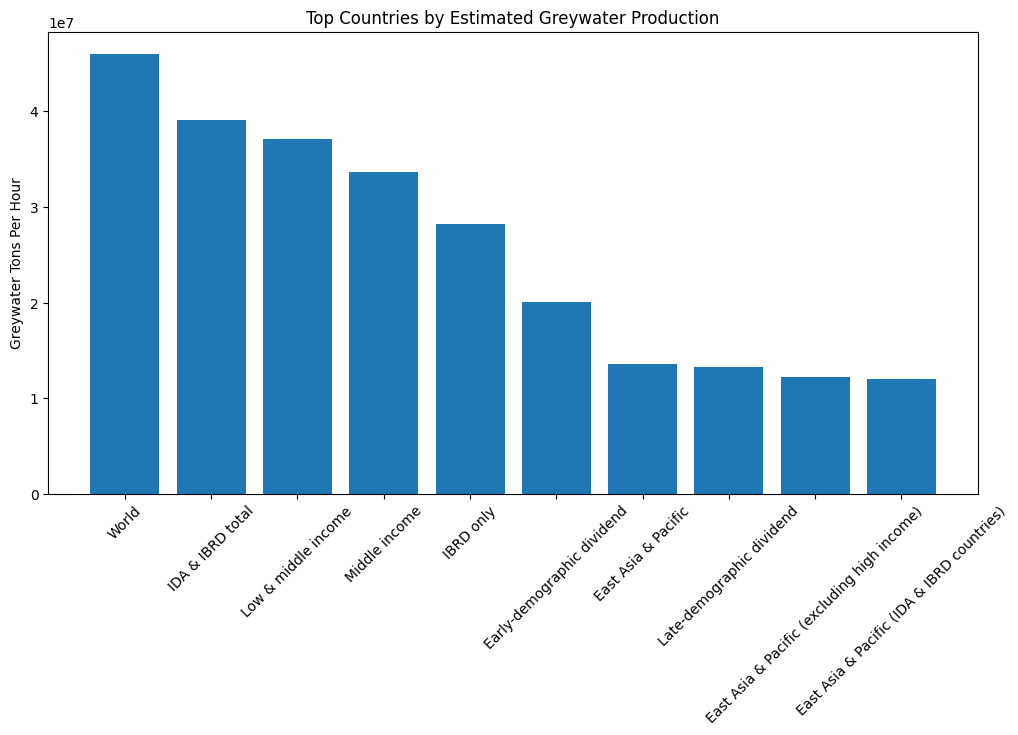

In [6]:
plt.figure(figsize=(12,6))

plt.bar(
    top_countries["country"],
    top_countries["greywater_tons_per_hour"]
)

plt.xticks(rotation=45)

plt.ylabel("Greywater Tons Per Hour")

plt.title("Top Countries by Estimated Greywater Production")

plt.show()

In [7]:
population_df.to_csv(
    "global_greywater_estimates.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.
